## Importing libraries

In [23]:
import pandas as pd
import numpy as np

## Importing Dataset

In [24]:
ds = pd.read_csv("dataset.csv",sep=";")
ds.head(5)

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


## Dataset Information

In [25]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     2000 non-null   object
 1   emotion  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [26]:
ds['emotion'].value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

## Data Preprocessing

### Tweets usually contain:

- URLs
- special characters
- punctuation
- stopwords

`we need to remove them inorder to train the model properly`

#### Improve Text Cleaning

- Add lemmatization so words become their base form.
- eg: running -> run

In [27]:
# run below once to download the datasets

# import nltk
# nltk.download('stopwords')
# nltk.download('wordnet')

In [28]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(tweet):

    text = tweet.lower()
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

#### Apply Cleaning

In [29]:
ds['clean_text'] = ds['text'].apply(clean_text)
ds.head()

,text,emotion,clean_text
0,im feeling rather rotten so im not very ambiti...,sadness,im feeling rather rotten im ambitious right
1,im updating my blog because i feel shitty,sadness,im updating blog feel shitty
2,i never make her separate from me because i do...,sadness,never make separate ever want feel like ashamed
3,i left with my bouquet of red and yellow tulip...,joy,left bouquet red yellow tulip arm feeling slig...
4,i was feeling a little vain when i did this one,sadness,feeling little vain one


# Text Vectorization (TF-IDF)

- Machine learning models cannot understand text directly.
- So we convert text into numerical vectors.

`NOTE : TF-IDF Stands - Term Frequency-Inverse Document Frequency`

#### Why this helps

- max_features=5000 → keeps the most useful words

- ngram_range=(1,2) → learns word combinations like

"very happy"

"not good"

- min_df=2 → removes rare words
- max_df=0.8 → removes overly common words

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8
)

X = vectorizer.fit_transform(ds['clean_text'])
y = ds['emotion']

# Train Test Split

#### We split data into:

- Training Data (80%)
- Testing Data (20%)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training the Model (Naive Bayes)

In [32]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.5) # alpha is the smoothing parameter, higher values can help with overfitting

model.fit(X_train, y_train)

,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None


# Making Predictions

In [33]:
y_pred = model.predict(X_test)

# Model Evaluation

In [34]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6425
              precision    recall  f1-score   support

       anger       0.89      0.31      0.46        52
        fear       0.73      0.26      0.38        43
         joy       0.60      0.95      0.73       131
        love       1.00      0.03      0.06        35
     sadness       0.66      0.85      0.74       124
    surprise       0.00      0.00      0.00        15

    accuracy                           0.64       400
   macro avg       0.65      0.40      0.39       400
weighted avg       0.68      0.64      0.58       400



d:\DS & ML\projects\twitter-comments-analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DS & ML\projects\twitter-comments-analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DS & ML\projects\twitter-comments-analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

# Testing with Custom Tweet

In [38]:
tweet = ["I am not going to eat icecream since india lost the match"]

tweet_vector = vectorizer.transform(tweet)

prediction = model.predict(tweet_vector)

print("Predicted Emotion:", prediction[0])

Predicted Emotion: sadness


# Visualization

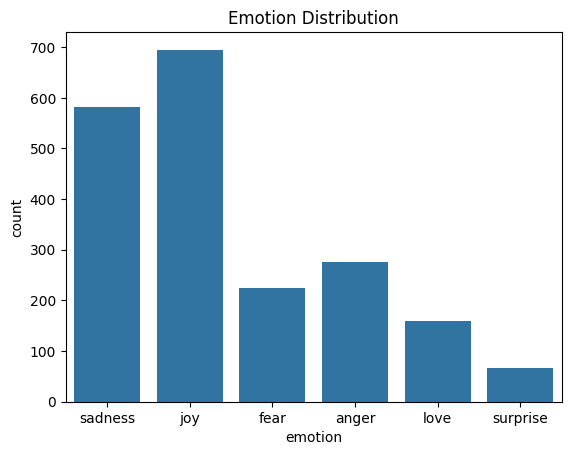

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='emotion', data=ds)
plt.title("Emotion Distribution")
plt.show()